# Fly species Identification using Wing Venation Patterns - A Deep Learning Approach

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from sklearn.model_selection import train_test_split

# --- Image Classification Base Class ---
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        "calculate loss for a batch of training data"
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        "calculate loss & accuracy for a batch of validation data"
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


# --- ResNet9 Model ---
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channels),
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(ImageClassificationBase):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        # Input: 128 x 3 x 64 x 64
        self.conv1 = conv_block(in_channels, 64) # 128 x 64 x 64 x 64
        self.conv2 = conv_block(64, 128, pool=True) # 128 x 128 x 32 x 32
        self.res1 = nn.Sequential(conv_block(128, 128), # 128 x 128 x 32 x 32
                                  conv_block(128, 128)) # 128 x 128 x 32 x 32

        self.conv3 = conv_block(128, 256, pool=True) # 128 x 256 x 16 x 16
        self.conv4 = conv_block(256, 512, pool=True) # 128 x 512 x 8 x 8
        self.res2 = nn.Sequential(conv_block(512, 512), # 128 x 512 x 8 x 8
                                  conv_block(512, 512)) # 128 x 512 x 8 x 8

        self.classifier = nn.Sequential(nn.AdaptiveMaxPool2d(1), # 128 x 512 x 1 x 1
                                        nn.Flatten(), # 128 x 512
                                        nn.Dropout(0.2),
                                        nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out


In [4]:
# --- Data Preparation ---
train_data_dir = '/content/drive/MyDrive/mh_resnet/fold5/train'
test_data_dir = '/content/drive/MyDrive/mh_resnet/fold5/test'

train_dataset = ImageFolder(train_data_dir, tt.Compose([tt.Grayscale(),
                                                        tt.ToTensor()]))
test_dataset = ImageFolder(test_data_dir, tt.Compose([tt.Grayscale(),
                                                      tt.ToTensor()]))

train_ds, valid_ds = train_test_split(train_dataset, test_size = 0.2, random_state=42, stratify=train_dataset.targets)
test_ds = test_dataset

batch_size = 32

train_dl = DataLoader(train_ds,
                      batch_size,
                      shuffle=True,
                      num_workers=2,
                      pin_memory=True)

valid_dl = DataLoader(valid_ds,
                    batch_size,
                    num_workers=2,
                    pin_memory=True)

In [5]:
# --- Model Training ---
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

device = get_default_device()

train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

@torch.no_grad()
def evaluate(model, val_loader):
    """Evaluates the model's performance on the validation set"""
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

model = to_device(ResNet9(1, len(train_dataset.classes)), device)

history = [evaluate(model, valid_dl)]
history += fit(40, 0.001, model, train_dl, valid_dl, torch.optim.Adam)
history += fit(40, 0.0001, model, train_dl, valid_dl, torch.optim.Adam)
history += fit(40, 0.00001, model, train_dl, valid_dl, torch.optim.Adam)

Epoch [0], train_loss: 4.4641, val_loss: 2.7079, val_acc: 0.0861
Epoch [1], train_loss: 2.7990, val_loss: 2.6108, val_acc: 0.1056
Epoch [2], train_loss: 2.3872, val_loss: 2.6409, val_acc: 0.1292
Epoch [3], train_loss: 2.1094, val_loss: 2.3437, val_acc: 0.1708
Epoch [4], train_loss: 1.7000, val_loss: 2.3895, val_acc: 0.1812
Epoch [5], train_loss: 1.5019, val_loss: 1.8141, val_acc: 0.4264
Epoch [6], train_loss: 1.0864, val_loss: 1.4780, val_acc: 0.5868
Epoch [7], train_loss: 0.8149, val_loss: 1.2810, val_acc: 0.5764
Epoch [8], train_loss: 0.5726, val_loss: 0.9436, val_acc: 0.6597
Epoch [9], train_loss: 0.5044, val_loss: 0.6774, val_acc: 0.7875
Epoch [10], train_loss: 0.5419, val_loss: 0.4821, val_acc: 0.8083
Epoch [11], train_loss: 0.4142, val_loss: 0.6473, val_acc: 0.7979
Epoch [12], train_loss: 0.3585, val_loss: 0.4124, val_acc: 0.8722
Epoch [13], train_loss: 0.2436, val_loss: 0.5548, val_acc: 0.7757
Epoch [14], train_loss: 0.2384, val_loss: 0.5480, val_acc: 0.8514
Epoch [15], train_lo

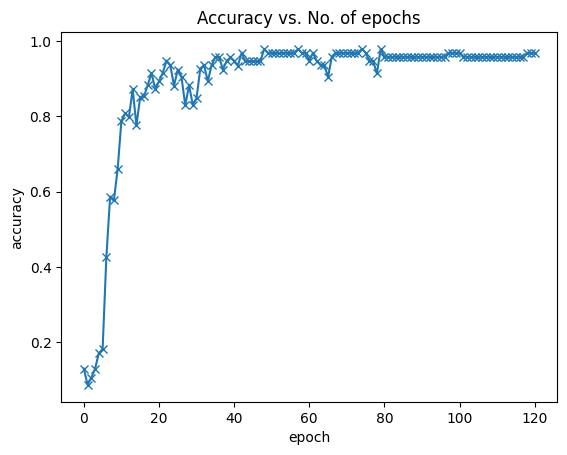

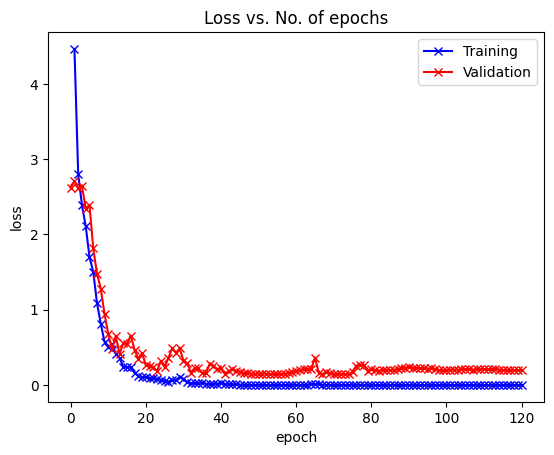

In [6]:
# --- Plotting ---
import matplotlib.pyplot as plt

def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs')

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs')

plot_accuracies(history)
plt.show()
plot_losses(history)
plt.show()

In [7]:
# Create a mapping from species to family
def familyClass(species_name):
  if species_name in ['C.vicina', 'Ch.albiceps', 'Ch.albiceps_mutant', 'Ch.bezziana', 'Ch.megacephala', 'Ch.nigripes', 'Ch.rufifacies', 'L.sericata']:
    return 'Calliphoridae'
  elif species_name in ['B.karnyi', 'Z.aquila', 'Le.alba', 'Se.princeps', 'A.gressitti']:
    return 'Sarcophagidae'
  else:
    return 'Muscidae'

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os
import pandas as pd

# Create a DataLoader for the test set to perform evaluation on all test images
test_dl = DeviceDataLoader(DataLoader(test_dataset, batch_size*2), device)

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            images, labels = batch
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

# Get predictions on the full test set
y_pred, y_true = get_predictions(model, test_dl)

# Get class names
class_names = train_dataset.classes

# --- Analyze incorrect predictions ---
# --- Create a DataFrame with predictions ---

# Create a list of dictionaries with all the required information
predictions_list = []
for i in range(len(y_true)):
    img_path, _ = test_dataset.samples[i]
    true_species = class_names[y_true[i]]
    pred_species = class_names[y_pred[i]]
    true_family = familyClass(true_species)
    pred_family = familyClass(pred_species)

    predictions_list.append({
        'sample_name': os.path.basename(img_path),
        'species': true_species,
        'Prediction': pred_species,
        'TargetFamily': true_family,
        'PredictionFamily': pred_family,
        'Match': true_species == pred_species,
        'MatchFamily': true_family == pred_family
    })

# Create the DataFrame
test_df = pd.DataFrame(predictions_list)

# Display the wrongly predicted rows
wrong_predictions = test_df[test_df['Match'] == False]
print("Wrongly predicted rows:")
display(wrong_predictions[['sample_name', 'species', 'Prediction', 'TargetFamily','PredictionFamily']])


# --- Performance Metrics ---
def calculate_metrics(y_true, y_pred, class_names, labels=None):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0, labels=labels)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    sensitivity = np.diag(cm) / np.sum(cm, axis=1)
    specificity = []
    for i in range(len(class_names)):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(cm[:, i]) - cm[i, i]
        if (tn + fp) == 0:
            specificity.append(1.0)
        else:
            specificity.append(tn / (tn + fp))

    balanced_accuracy = (sensitivity + np.array(specificity)) / 2

    return report, sensitivity, specificity, balanced_accuracy

# Species-level metrics
report_species, sensitivity_species, specificity_species, balanced_accuracy_species = calculate_metrics(y_true, y_pred, class_names, labels=np.arange(len(class_names)))

print("\n--- Species Level Metrics ---")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
avg_sensitivity_species = np.mean(sensitivity_species)
avg_specificity_species = np.mean(specificity_species)
avg_balanced_accuracy_species = np.mean(balanced_accuracy_species)
print(f"Averaged Sensitivity (Recall): {avg_sensitivity_species:.4f}")
print(f"Averaged Specificity: {avg_specificity_species:.4f}")
print(f"Averaged Balanced Accuracy: {avg_balanced_accuracy_species:.4f}")
print("Test set accuracy (Species Level) = {:.2f}% ({} / {})".format(
    test_df['Match'].sum() / len(test_df) * 100, test_df['Match'].sum(), len(test_df)
))


Wrongly predicted rows:


,sample_name,species,Prediction,TargetFamily,PredictionFamily



--- Species Level Metrics ---
                    precision    recall  f1-score   support

       A.gressitti       1.00      1.00      1.00         3
          B.karnyi       1.00      1.00      1.00         4
          C.vicina       1.00      1.00      1.00        20
       Ch.albiceps       1.00      1.00      1.00        20
Ch.albiceps_mutant       1.00      1.00      1.00        20
       Ch.bezziana       1.00      1.00      1.00        12
    Ch.megacephala       1.00      1.00      1.00        17
       Ch.nigripes       1.00      1.00      1.00         2
     Ch.rufifacies       1.00      1.00      1.00         7
        L.sericata       1.00      1.00      1.00        20
           Le.alba       1.00      1.00      1.00         2
       Se.princeps       1.00      1.00      1.00         2
       Sy.nudiseta       1.00      1.00      1.00        19
          Z.aquila       1.00      1.00      1.00         4

          accuracy                           1.00       152
       

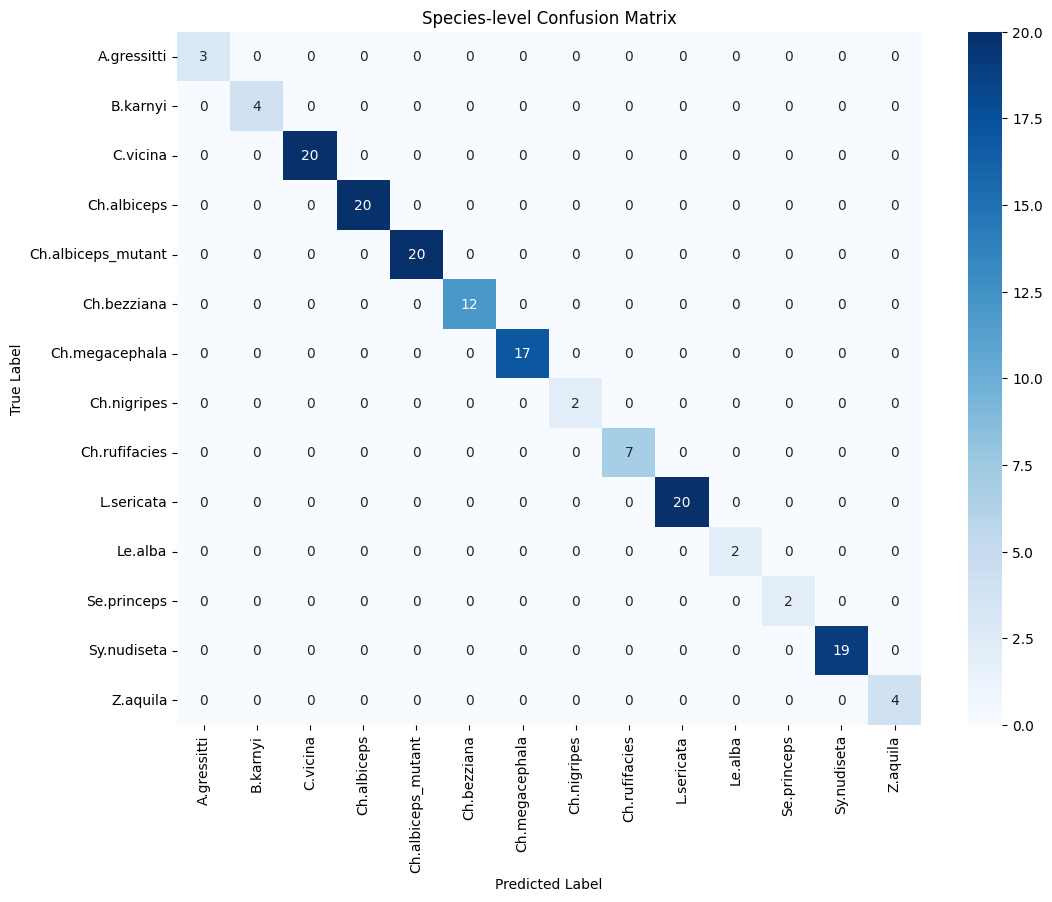

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Species-level confusion matrix
cm_species = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
plot_confusion_matrix(cm_species, class_names, title='Species-level Confusion Matrix')

